# Loading Dataset and CNN
*Rolando A. Pula*

This notebook is a runnable version of the "Loading Dataset and CNN" slide deck. It walks through:

1. Loading a Dogs vs. Cats image dataset with OpenCV
2. Preprocessing the images (grayscale, resize, shuffle)
3. Saving/loading the prepared data with `pickle`
4. Building and training a Convolutional Neural Network (CNN) with TensorFlow/Keras to classify dogs vs. cats

> **Before you run this notebook:** download the Kaggle "Dogs vs. Cats" dataset (e.g. `https://www.kaggle.com/c/dogs-vs-cats/data` or the mirrored `salader/dogs-vs-cats` dataset on Kaggle) and unzip it so you have two folders, `Dog/` and `Cat/`, each full of `.jpg` images. Then set `DATADIR` below to point at the parent folder that contains `Dog/` and `Cat/`.

## Requirements for Image Processing

- **GPU** (optional, speeds up training but not required)
- **OpenCV** (`cv2`) – for image processing
- **os module** – lets Python interface with the OS running on your computer (already in the standard library)
- **Data** – we'll use the Kaggle "Dogs vs. Cats" dataset

Run the cell below once to install the packages this notebook needs (skip it if they're already installed in your environment).

In [1]:
# Run this once if the packages below aren't already installed.
# %pip install opencv-python numpy matplotlib tensorflow

## Checking and installing OpenCV

The original slides show installing OpenCV through **Anaconda Navigator** (Environments tab → search `opencv` → Install). If you're not using Anaconda, the `pip install opencv-python` command in the cell above does the same thing.

## Calling the Necessary Modules

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2

## Data Preparation

Set `DATADIR` to the folder on your machine that contains the `Dog` and `Cat` subfolders (this replaces the original slide's hard-coded Windows path, `C:/Users/admin/Desktop/AMEN/Deep_Learning_class/Kaggle_dataset/PetImages`, with something you can edit for your own machine).

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Unzipping the Dataset

Given that the dataset is in a `.zip` file in Google Drive, we need to unzip it to a local directory before processing. I'll unzip `PetImages.zip` to `/content/` and then set `DATADIR` to this new location.

In [4]:
import zipfile
import os

# Path to the zip file in Google Drive

zip_file_path = '/content/drive/MyDrive/PetImages.zip'

# Destination directory to unzip the files
destination_dir = '/content/'

# Create the destination directory if it doesn't exist
os.makedirs(destination_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(destination_dir)

print(f"Unzipped '{zip_file_path}' to '{destination_dir}'")

# The dataset will be unzipped into a folder named 'PetImages' inside destination_dir
# Update DATADIR to point to this unzipped location

Unzipped '/content/drive/MyDrive/PetImages.zip' to '/content/'


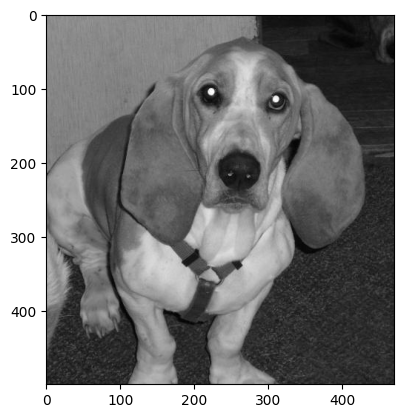

In [5]:
DATADIR = "/content/PetImages"  # <- change this to the path that contains your Dog/ and Cat/ folders
# this is the directory of your datasets
CATEGORIES = ["Dog", "Cat"]   # Defining the label as "Dog" or "Cat"

for category in CATEGORIES:
    path = os.path.join(DATADIR, category)  # path to cats or dogs dir
    for img in os.listdir(path):
        img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_GRAYSCALE)
        if img_array is None:
            # a handful of files in the Kaggle dataset are corrupted/unreadable - skip them
            continue

        # reading the image in the path and transforming it into an array
        # cv2.IMREAD_GRAYSCALE converts the image to grayscale so the CNN only has
        # to learn from one color channel instead of three (faster, smaller model)

        plt.imshow(img_array, cmap="gray")
        plt.show()
        break
    break

## Image Inspection

In [6]:
print(img_array)          # Displaying the image in array form (just for checking)
print(img_array.shape)    # checking the resolution of the image

[[148 144 140 ...  70  76  82]
 [148 144 140 ...  69  77  81]
 [147 144 140 ...  67  76  78]
 ...
 [ 45  40  47 ...  42  45  50]
 [ 45  41  52 ...  45  46  50]
 [ 38  35  50 ...  46  44  45]]
(500, 471)


## Image Resizing

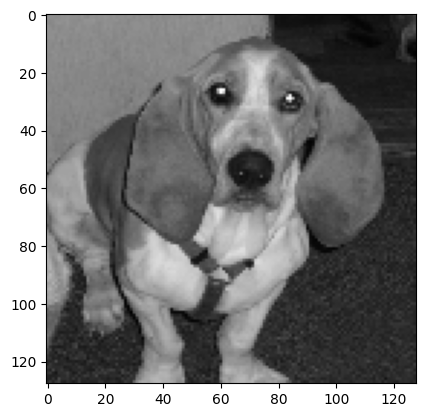

In [7]:
IMG_SIZE = 128  # initializing variable "IMG_SIZE" as 100

new_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
plt.imshow(new_array, cmap='gray')
plt.show()

## Assigning Training Data

In [8]:
training_data = []  # assigning training data

def create_training_data():
    for category in CATEGORIES:
        path = os.path.join(DATADIR, category)  # path to cats or dogs dir
        class_num = CATEGORIES.index(category)
        for img in os.listdir(path):
            try:
                img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_GRAYSCALE)
                new_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
                training_data.append([new_array, class_num])
            except Exception as e:
                pass

create_training_data()

## Checking the Number of Training Data

In [9]:
print(len(training_data))

24997


## Randomizing/Shuffling the Data

In [10]:
import random
random.shuffle(training_data)

for sample in training_data[:10]:
    print(sample[1])

1
1
1
1
1
0
1
0
1
1


## Assigning Variables for Features and Labels

In [11]:
X = []  # feature set
y = []  # labels

for features, label in training_data:
    X.append(features)
    y.append(label)

X = np.array(X).reshape(-1, IMG_SIZE, IMG_SIZE, 1)  # 1 is for grayscale
y = np.array(y)  # Keras expects the labels as an array too

## Using the Pickle Module

In [12]:
import pickle  # pickle lets you save your training data, avoiding recreating it
                # from scratch every time you want to adjust the model

with open('X.pickle', 'wb') as f:
    pickle.dump(X, f)

with open('y.pickle', 'wb') as g:
    pickle.dump(y, g)

## Using Pickle (Loading It Back)

In [13]:
pickle_in = open('X.pickle', 'rb')
X = pickle.load(pickle_in)

X[1]

array([[[18],
        [18],
        [20],
        ...,
        [59],
        [63],
        [53]],

       [[19],
        [21],
        [19],
        ...,
        [70],
        [62],
        [47]],

       [[16],
        [20],
        [21],
        ...,
        [75],
        [60],
        [41]],

       ...,

       [[29],
        [24],
        [35],
        ...,
        [21],
        [21],
        [23]],

       [[26],
        [26],
        [29],
        ...,
        [23],
        [20],
        [20]],

       [[25],
        [27],
        [29],
        ...,
        [22],
        [19],
        [20]]], dtype=uint8)

## What is a CNN?

**CNN** stands for **Convolutional Neural Network** — a type of neural network especially well suited to image data because it learns spatial patterns (edges, textures, shapes) through convolution and pooling layers instead of treating every pixel independently.

Further reading:
- https://medium.com/data-science-group-iitr/building-a-convolutional-neural-network-in-python-with-tensorflow-d251c3ca8117
- https://hackernoon.com/what-is-a-capsnet-or-capsule-network-2bfbe48769cc

## Using a CNN for Classification of Images

In [14]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, Activation, Flatten, Conv2D, MaxPooling2D
import pickle

X = pickle.load(open('X.pickle', 'rb'))
y = pickle.load(open('y.pickle', 'rb'))

## Building, Compiling, and Training the CNN

`X = X/255.0` normalizes the pixel values (0-255) down to the 0-1 range, which helps the network train faster and more stably.

> Training for the full 200 epochs on the whole dataset can take a long time on CPU. Reduce `epochs` (e.g. to 10) for a quick test run, and increase it back up once you know the pipeline works.

In [15]:
X = X / 255.0

model = Sequential()
model.add(Input(shape=X.shape[1:]))

#model.add(Conv2D(2, (3, 3)))
model.add(Conv2D(64, (3, 3)))
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(64, (3, 3)))
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(64, (3, 3)))
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())
model.add(Dense(64))
model.add(Dense(64))
model.add(Dense(1))
model.add(Activation('sigmoid'))

model.compile(loss="binary_crossentropy",
              optimizer="adam",
              metrics=['accuracy'])



In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 126, 126, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 61, 61, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       802,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 881,601 (3.36 MB)

 Trainable params: 881,601 (3.36 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import numpy as np

# Save the model whenever validation accuracy improves
checkpoint = ModelCheckpoint(
    '/content/drive/MyDrive/best_cnn_model.keras',
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

# Stop training when validation accuracy stops improving
early_stopping = EarlyStopping(
    monitor='val_accuracy',
    mode='max',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

# Train the CNN
history = model.fit(
    X,
    y,
    batch_size=128,
    epochs=30,
    validation_split=0.2,
    callbacks=[checkpoint, early_stopping]
)

# Automatically identify the best epoch
best_epoch = np.argmax(history.history['val_accuracy']) + 1
best_val_accuracy = max(history.history['val_accuracy'])

print("\n==============================")
print("BEST CNN MODEL")
print("==============================")
print(f"Best Epoch: {best_epoch}")
print(f"Best Validation Accuracy: {best_val_accuracy:.4f}")
print(f"Best Validation Accuracy: {best_val_accuracy * 100:.2f}%")
print("Best model saved to:")
print("/content/drive/MyDrive/best_cnn_model.keras")
print("==============================")


Epoch 1/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5755 - loss: 0.6785
Epoch 1: val_accuracy improved from None to 0.71760, saving model to /content/drive/MyDrive/best_cnn_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/best_cnn_model.keras
157/157 ━━━━━━━━━━━━━━━━━━━━ 645s 4s/step - accuracy: 0.6292 - loss: 0.6380 - val_accuracy: 0.7176 - val_loss: 0.5627
Epoch 2/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7334 - loss: 0.5363
Epoch 2: val_accuracy improved from 0.71760 to 0.75240, saving model to /content/drive/MyDrive/best_cnn_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/best_cnn_model.keras
157/157 ━━━━━━━━━━━━━━━━━━━━ 629s 4s/step - accuracy: 0.7414 - loss: 0.5249 - val_accuracy: 0.7524 - val_loss: 0.5149
Epoch 3/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7713 - loss: 0.4773
Epoch 3: val_accuracy improved from 0.75240 to 0.77560, saving model to /content/drive/MyDrive/best_cnn_model.keras

Epoch

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 126, 126, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 61, 61, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       802,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,644,805 (10.09 MB)

 Trainable params: 881,601 (3.36 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,763,204 (6.73 MB)

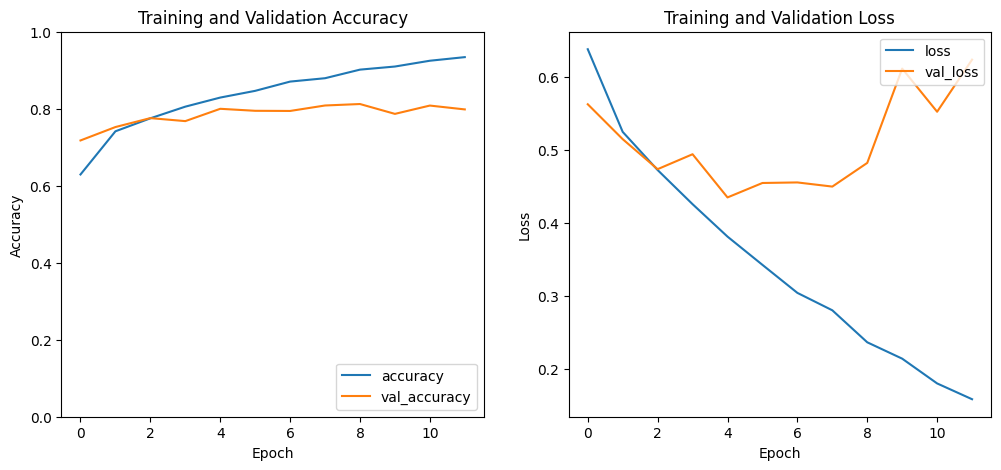

782/782 ━━━━━━━━━━━━━━━━━━━━ 190s 243ms/step

Confusion Matrix:
[[11493  1006]
 [ 1303 11195]]


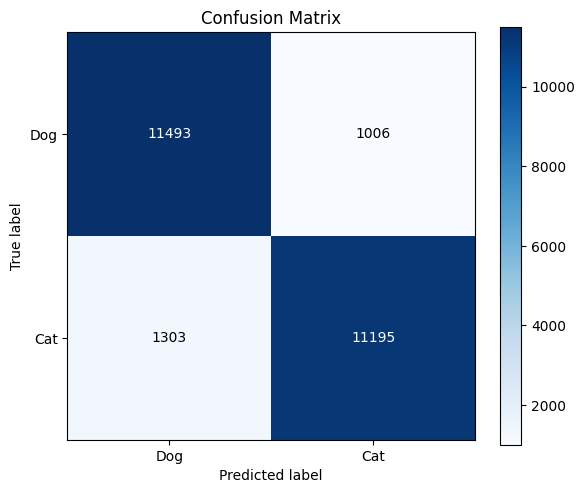

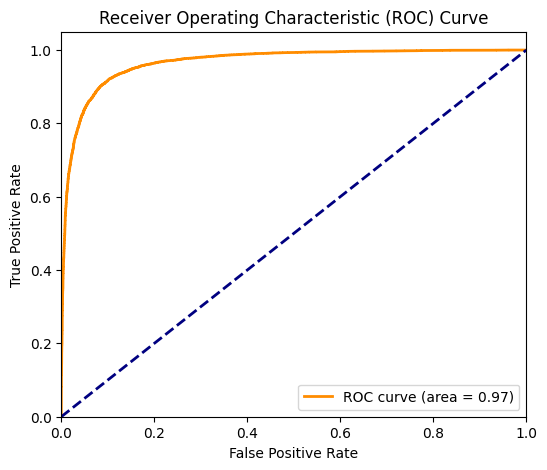

In [18]:
model.summary()

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc
import numpy as np # numpy is already imported as np earlier

# Plot training accuracy and loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()

# Get predictions for confusion matrix and ROC
y_pred_proba = model.predict(X).ravel() # .ravel() to flatten to 1D array
y_pred = (y_pred_proba > 0.5).astype(int)

# Confusion Matrix
cm = confusion_matrix(y, y_pred)
print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(len(np.unique(y)))
CATEGORIES = ["Dog", "Cat"]
plt.xticks(tick_marks, CATEGORIES)
plt.yticks(tick_marks, CATEGORIES)
plt.ylabel('True label')
plt.xlabel('Predicted label')
fmt = 'd'
thresh = cm.max() / 2.
for i, j in np.ndindex(cm.shape):
    plt.text(j, i, format(cm[i, j], fmt),
             ha="center", va="center",
             color="white" if cm[i, j] > thresh else "black")
plt.tight_layout()
plt.show()

# ROC Curve and AUC
fpr, tpr, thresholds = roc_curve(y, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [19]:
import tensorflow as tf

# Define the filename for your model
model_filename = 'dog_cat_classifier.keras' # .keras is the recommended extension for Keras models

# Save the model
model.save(model_filename)
print(f"Model saved to {model_filename}")

# To load the model later (you can do this in a new session or script)
loaded_model = tf.keras.models.load_model(model_filename)
print(f"Model loaded from {model_filename}")

# You can then use the loaded_model for predictions or further evaluation
# For example, let's make predictions with the loaded model and compare
loaded_model_predictions = loaded_model.predict(X)
print("\nExample predictions from loaded model:")
print(loaded_model_predictions[:5])


Model saved to dog_cat_classifier.keras
Model loaded from dog_cat_classifier.keras
782/782 ━━━━━━━━━━━━━━━━━━━━ 201s 257ms/step

Example predictions from loaded model:
[[0.961692  ]
 [0.8379887 ]
 [0.55391836]
 [0.9849811 ]
 [0.99274945]]


## Prediction Inference

Now that the model is loaded, we can use it to make predictions on new, unseen data. For demonstration purposes, I'll take a few samples from your existing `X` data to illustrate how to get predictions from the `loaded_model`.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
Predictions for the test samples:
Sample 1: Predicted Class = Cat (Probability: 96.17%) 
Sample 2: Predicted Class = Cat (Probability: 83.80%) 
Sample 3: Predicted Class = Cat (Probability: 55.39%) 
Sample 4: Predicted Class = Cat (Probability: 98.50%) 
Sample 5: Predicted Class = Cat (Probability: 99.27%) 


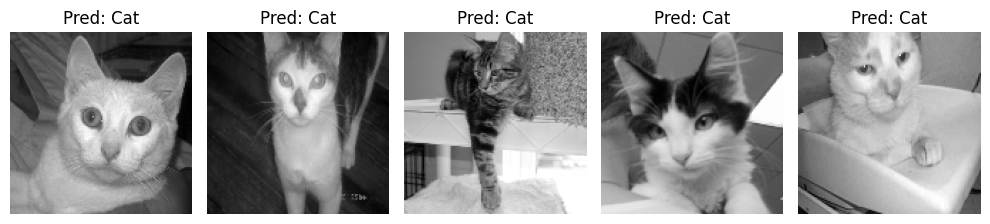

In [20]:
# Select a small subset of data for inference (e.g., the first 5 samples)
# In a real scenario, this would be entirely new, unseen test data.
test_samples = X[:5]

# Make predictions using the loaded model
inference_predictions = loaded_model.predict(test_samples)

print("Predictions for the test samples:")
for i, prediction in enumerate(inference_predictions):
    # Assuming binary classification with sigmoid output, values close to 1 are 'Cat', close to 0 are 'Dog'
    predicted_class = 'Cat' if prediction[0] > 0.5 else 'Dog'
    probability = prediction[0] * 100
    print(f"Sample {i+1}: Predicted Class = {predicted_class} (Probability: {probability:.2f}%) ")

# Optionally, display the images and their predictions
plt.figure(figsize=(10, 4))
for i in range(min(5, len(test_samples))):
    plt.subplot(1, 5, i + 1)
    plt.imshow(test_samples[i].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
    predicted_class = 'Cat' if inference_predictions[i][0] > 0.5 else 'Dog'
    plt.title(f"Pred: {predicted_class}")
    plt.axis('off')
plt.tight_layout()
plt.show()